<a href="https://colab.research.google.com/github/Not-kh-lily-23/pulsar-conformal-triage/blob/main/medlat_replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from google.colab import drive
drive.mount('/content/drive')
medlat_path='/content/drive/MyDrive/pulsar_project/data/processed/medlat_full.csv'
df=pd.read_csv(medlat_path).dropna()
x=x.drop(columns=['dm','topo_period','width','snr'],errors='ignore')
y=df['target']
print(f"total number of rows are {len(df)}")
print(f"positive class ration: {(y.sum()/len(y))*100:.2f}")
x_temp,x_test,y_temp,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
x_train,x_calib,y_train,y_calib=train_test_split(x_temp,y_temp,test_size=0.25,random_state=42,stratify=y_temp)
print(f"splits to train: {len(y_train)} | caliberation: {len(y_calib)} | test: {len(y_test)}")
clf=lgb.LGBMClassifier(random_state=42,n_estimators=100,verbose=-1)
clf.fit(x_train,y_train)
print("done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total number of rows are 91192
positive class ration: 1.31
splits to train: 54714 | caliberation: 18239 | test: 18239
done


In [9]:
import numpy as np
calib_prob=clf.predict_proba(x_calib)
test_prob=clf.predict_proba(x_test)
calib_scores=1-calib_prob[np.arange(len(y_calib)),y_calib]
test_scores_true=1-test_prob[np.arange(len(y_test)), y_test]
alpha=0.05
target_cov=1-alpha
n_calib=len(calib_scores)
q_marg=np.quantile(calib_scores,min(1.0,np.ceil((n_calib+1)*target_cov)/n_calib))
marg_cov_0=np.mean(test_scores_true[y_test==0]<=q_marg)
marg_cov_1=np.mean(test_scores_true[y_test==1]<=q_marg)
scores_0=calib_scores[y_calib==0]
scores_1=calib_scores[y_calib==1]
n_0=len(scores_0)
n_1=len(scores_1)
q_0=np.quantile(scores_0,min(1.0,np.ceil((n_0+1)*target_cov)/n_0))
q_1=np.quantile(scores_1,min(1.0,np.ceil((n_1+1)*target_cov)/n_1))
mondrian_cov_0=np.mean(test_scores_true[y_test==0]<=q_0)
mondrian_cov_1=np.mean(test_scores_true[y_test==1]<=q_1)
print(f"target discovery floor: {target_cov:.4f}")
print("marginal cp (standard model):")
print(f"class 0 (noise) coverage: {marg_cov_0:.4f}")
print(f"class 1 (pulsar) coverage: {marg_cov_1:.4f}")
print("mondrian cp (class conditional):")
print(f"class 0 (noise) coverage: {mondrian_cov_0:.4f}")
print(f"class 1 (pulsar) xoverage: {mondrian_cov_1:.4f}")

target discovery floor: 0.9500
marginal cp (standard model):
class 0 (noise) coverage: 0.9617
class 1 (pulsar) coverage: 0.0000
mondrian cp (class conditional):
class 0 (noise) coverage: 0.9495
class 1 (pulsar) xoverage: 0.9707


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import scipy.stats as st
n_seeds=20
alpha=0.05
target_cov=1-alpha
mond_cov_1_list=[]
marg_cov_1_list=[]
for seed in range(n_seeds):
    x_temp,x_test,y_temp,y_test=train_test_split(x,y,test_size=0.20,random_state=seed,stratify=y)
    x_train,x_calib,y_train,y_calib=train_test_split(x_temp,y_temp,test_size=0.25,random_state=seed,stratify=y_temp)
    clf=lgb.LGBMClassifier(random_state=seed,n_estimators=100,verbose=-1)
    clf.fit(x_train,y_train)
    calib_prob=clf.predict_proba(x_calib)
    test_prob=clf.predict_proba(x_test)
    calib_scores=1-calib_prob[np.arange(len(y_calib)),y_calib]
    test_scores_true=1-test_prob[np.arange(len(y_test)),y_test]
    n_calib=len(calib_scores)
    q_marg=np.quantile(calib_scores,min(1.0,np.ceil((n_calib+1)*target_cov)/n_calib))
    marg_cov_1_list.append(np.mean(test_scores_true[y_test==1]<=q_marg))
    scores_1=calib_scores[y_calib==1]
    n_1=len(scores_1)
    if n_1>0:
        q_1=np.quantile(scores_1,min(1.0,np.ceil((n_1+1)*target_cov)/n_1))
        mond_cov_1_list.append(np.mean(test_scores_true[y_test==1]<=q_1))
    if (seed+1)%5==0:
        print(f"completed seed{seed+1}/{n_seeds}")
def calc_ci(data):
    mean=np.mean(data)
    ci=st.t.interval(0.95,len(data)-1,loc=mean,scale=st.sem(data))
    return mean,ci[0],ci[1]
marg_mean,marg_lower,marg_upper=calc_ci(marg_cov_1_list)
mond_mean,mond_lower,mond_upper=calc_ci(mond_cov_1_list)
print(f"target coverage: {target_cov:.4f}")
print("marginal cp (class 1 - pulsar):")
print(f"mean Coverage: {marg_mean:.4f} [95% CI: {marg_lower:.4f} - {marg_upper:.4f}]")
print("mondrian cp (class 1 - pulsar):")
print(f"mean Coverage: {mond_mean:.4f} [95% CI: {mond_lower:.4f} - {mond_upper:.4f}]")

completed seed5/20
completed seed10/20
completed seed15/20
completed seed20/20
target coverage: 0.9500
marginal cp (class 1 - pulsar):
mean Coverage: 0.0238 [95% CI: 0.0083 - 0.0394]
mondrian cp (class 1 - pulsar):
mean Coverage: 0.9605 [95% CI: 0.9538 - 0.9672]


standard ml - fp: 16, fn: 38
balanced ml - fp: 53, fn: 14
mondrian cp - fp: 107, fn: 1, deferred: 0


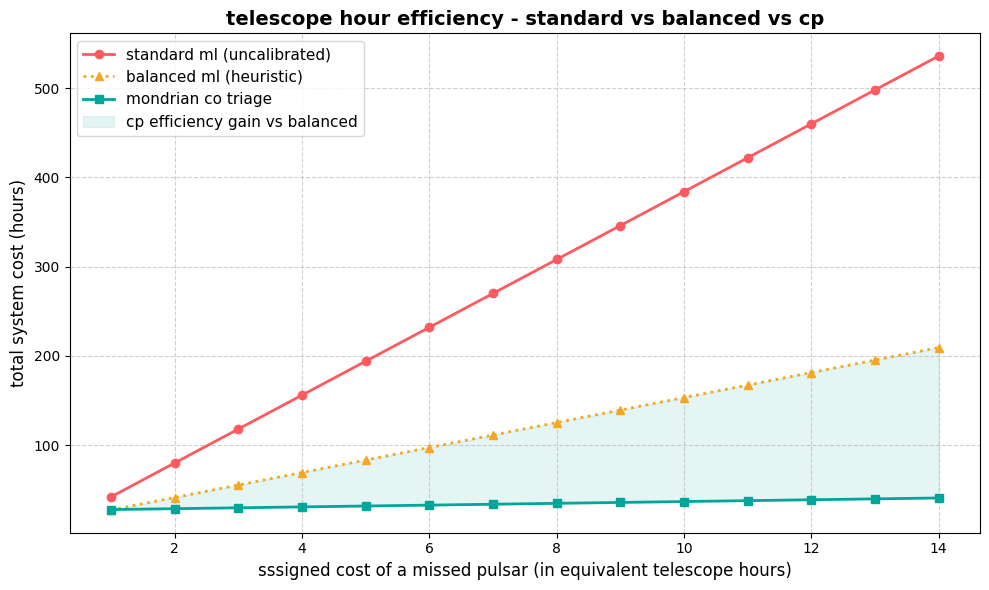

If missing a real pulsar is worse than wasting 2 hours of telescope time, mondrian bp mathematically beats the balanced baseline.


In [11]:
import matplotlib.pyplot as plt
def gen_predsets(test_probs,q_0,q_1):
    inc_0=(1-test_probs[:,0])<=q_0
    inc_1=(1-test_probs[:,1])<=q_1
    labels=[]
    for i0, i1 in zip(inc_0,inc_1):
        if i0 and not i1:
            labels.append("discard (definitive noise)")
        elif not i0 and i1:
            labels.append("telescope (definitive pulsar)")
        elif i0 and i1:
            labels.append("defer (ambiguous)")
        else:
            labels.append("anomaly (empty set)")
    return np.array(labels)
triage_des=gen_predsets(test_prob,q_0,q_1)
rdf=pd.DataFrame({
    'true_label':y_test.values,
    'prob_pulsar':test_prob[:,1],
    'triage_decision':triage_des
})
standard_preds=(test_prob[:,1]>=0.5).astype(int)
std_fp=np.sum((standard_preds==1)&(y_test==0))
std_fn=np.sum((standard_preds==0)&(y_test==1))
clf_bal=lgb.LGBMClassifier(random_state=42,n_estimators=100,class_weight='balanced',verbose=-1)
clf_bal.fit(x_train,y_train)
bal_preds=clf_bal.predict(x_test)
bal_fp=np.sum((bal_preds==1)&(y_test==0))
bal_fn=np.sum((bal_preds==0)&(y_test==1))
cp_fp=np.sum((rdf['triage_decision']=="telescope (definitive pulsar)")&(rdf['true_label']==0))
cp_fn=np.sum((rdf['triage_decision']=="discard (definitive noise)")&(rdf['true_label']==1))
cp_deferrals=np.sum(rdf['triage_decision']=="defer (ambiguous)")
print(f"standard ml - fp: {std_fp}, fn: {std_fn}")
print(f"balanced ml - fp: {bal_fp}, fn: {bal_fn}")
print(f"mondrian cp - fp: {cp_fp}, fn: {cp_fn}, deferred: {cp_deferrals}")
cost_telescope_pnt=0.25
cost_human_review=0.0
std_wsd_hrs=std_fp*cost_telescope_pnt
bal_wsd_hrs=bal_fp*cost_telescope_pnt
cp_wasted_hours=(cp_fp*cost_telescope_pnt)+(cp_deferrals*cost_human_review)
missed_pulsar_plt=np.arange(1,15,1)
std_tl_costs=[]
bal_tl_costs=[]
cp_tl_costs=[]
for penalty in missed_pulsar_plt:
    std_tl_costs.append(std_wsd_hrs+(std_fn*penalty))
    bal_tl_costs.append(bal_wsd_hrs+(bal_fn*penalty))
    cp_tl_costs.append(cp_wasted_hours+(cp_fn*penalty))
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(missed_pulsar_plt,std_tl_costs,marker='o',label='standard ml (uncalibrated)',color='#ff5a5f',linewidth=2)
ax.plot(missed_pulsar_plt,bal_tl_costs,marker='^',label='balanced ml (heuristic)',color='#f5a623',linewidth=2,linestyle=':')
ax.plot(missed_pulsar_plt,cp_tl_costs,marker='s',label='mondrian co triage',color='#00a699',linewidth=2)
ax.fill_between(missed_pulsar_plt,bal_tl_costs,cp_tl_costs,
                where=(np.array(bal_tl_costs)>np.array(cp_tl_costs)),
                interpolate=True,color='#00a699',alpha=0.1,label='cp efficiency gain vs balanced')
ax.set_xlabel('sssigned cost of a missed pulsar (in equivalent telescope hours)',fontsize=12)
ax.set_ylabel('total system cost (hours)',fontsize=12)
ax.set_title('telescope hour efficiency - standard vs balanced vs cp',fontsize=14,fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()
diffs=np.array(bal_tl_costs)-np.array(cp_tl_costs)
bei=np.where(diffs>0)[0]
if len(bei)>0:
    bep=missed_pulsar_plt[bei[0]]
    print(f"If missing a real pulsar is worse than wasting {bep} hours of telescope time, mondrian bp mathematically beats the balanced baseline.")